In [1]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("/content/train.csv")

In [3]:
df.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


In [4]:
df.drop(columns=["ID"],axis=1,inplace=True)

In [5]:
df.shape

(8068, 10)

In [6]:
df.dropna(inplace=True)

In [7]:
df.isnull().sum()

,0
Gender,0
Ever_Married,0
Age,0
Graduated,0
Profession,0
Work_Experience,0
Spending_Score,0
Family_Size,0
Var_1,0
Segmentation,0


In [8]:
df.shape

(6665, 10)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6665 entries, 0 to 8067
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Gender           6665 non-null   object 
 1   Ever_Married     6665 non-null   object 
 2   Age              6665 non-null   int64  
 3   Graduated        6665 non-null   object 
 4   Profession       6665 non-null   object 
 5   Work_Experience  6665 non-null   float64
 6   Spending_Score   6665 non-null   object 
 7   Family_Size      6665 non-null   float64
 8   Var_1            6665 non-null   object 
 9   Segmentation     6665 non-null   object 
dtypes: float64(2), int64(1), object(7)
memory usage: 572.8+ KB


In [10]:
df.describe()

,Age,Work_Experience,Family_Size
count,6665.000000,6665.000000,6665.000000
mean,43.536084,2.629107,2.841110
std,16.524054,3.405365,1.524743
min,18.000000,0.000000,1.000000
25%,31.000000,0.000000,2.000000
50%,41.000000,1.000000,2.000000
75%,53.000000,4.000000,4.000000
max,89.000000,14.000000,9.000000


In [11]:
df.head()

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
2,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
5,Male,Yes,56,No,Artist,0.0,Average,2.0,Cat_6,C
6,Male,No,32,Yes,Healthcare,1.0,Low,3.0,Cat_6,C


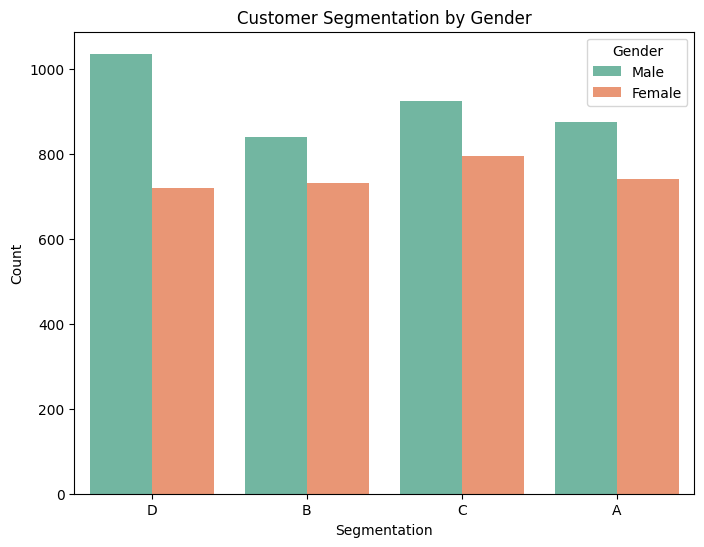

In [12]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Segmentation', hue='Gender', palette='Set2')
plt.title('Customer Segmentation by Gender')
plt.xlabel('Segmentation')
plt.ylabel('Count')
plt.legend(title='Gender')
plt.show()

/tmp/ipython-input-3354522588.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Segmentation', y='Age', palette='Set3')


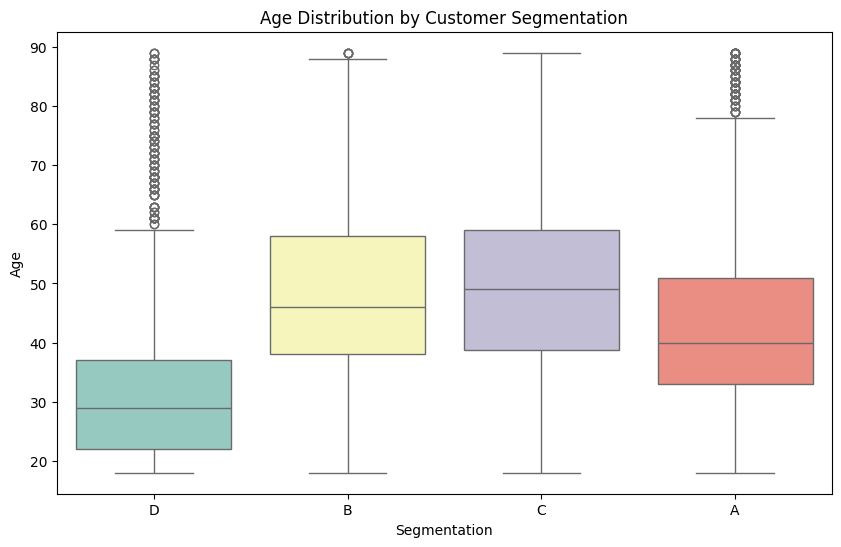

In [13]:
# Box plot of Age by Segmentation
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Segmentation', y='Age', palette='Set3')
plt.title('Age Distribution by Customer Segmentation')
plt.xlabel('Segmentation')
plt.ylabel('Age')
plt.show()

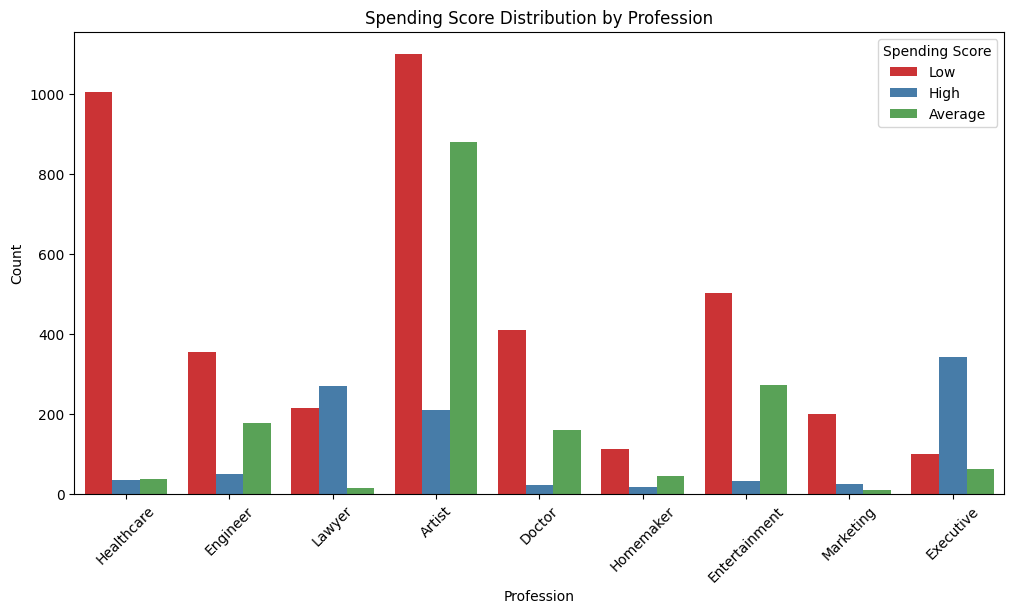

In [14]:
# Count plot of Spending Score by Profession
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Profession', hue='Spending_Score', palette='Set1')
plt.title('Spending Score Distribution by Profession')
plt.xlabel('Profession')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Spending Score')
plt.show()

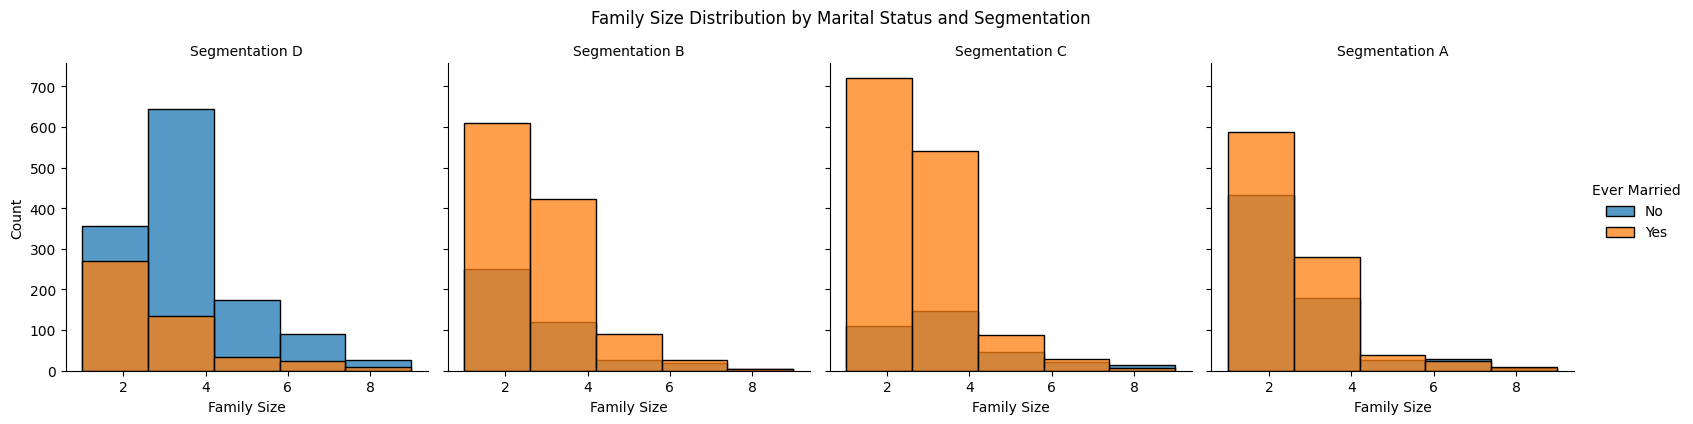

In [16]:
# FacetGrid for Family Size by Ever Married and Segmentation
g = sns.FacetGrid(df, col='Segmentation', hue='Ever_Married', height=4, aspect=1)
g.map(sns.histplot, 'Family_Size', bins=5)
g.add_legend(title='Ever Married')
g.set_titles('Segmentation {col_name}')
g.set_axis_labels('Family Size', 'Count')
plt.suptitle('Family Size Distribution by Marital Status and Segmentation', y=1.05)
plt.show()

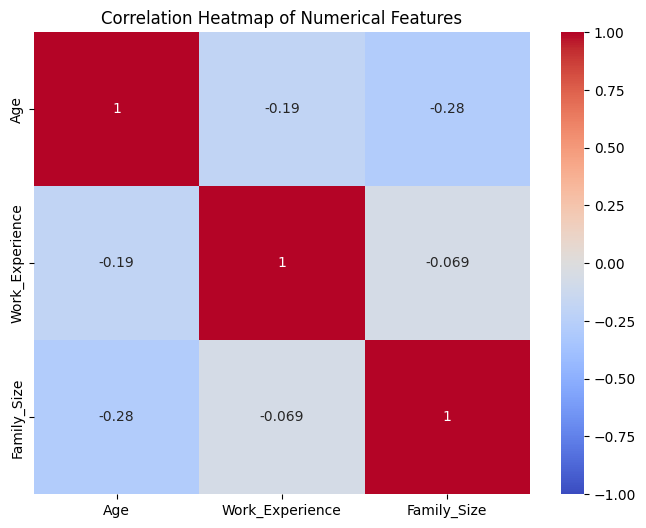

In [17]:
# Correlation heatmap for numerical features
plt.figure(figsize=(8, 6))
numerical_cols = ['Age', 'Work_Experience', 'Family_Size']
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [18]:
df.head()

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
2,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
5,Male,Yes,56,No,Artist,0.0,Average,2.0,Cat_6,C
6,Male,No,32,Yes,Healthcare,1.0,Low,3.0,Cat_6,C


In [19]:
label_encoders = {}
mappings = []

for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    mapping = {class_: idx for idx, class_ in enumerate(le.classes_)}
    for k, v in mapping.items():
        mappings.append([col, k, v])

In [22]:
from tabulate import tabulate
print(tabulate(mappings, headers=["Column", "Original Value", "Encoded Value"], tablefmt="grid"))

+----------------+------------------+-----------------+
| Column         | Original Value   |   Encoded Value |
+================+==================+=================+
| Gender         | Female           |               0 |
+----------------+------------------+-----------------+
| Gender         | Male             |               1 |
+----------------+------------------+-----------------+
| Ever_Married   | No               |               0 |
+----------------+------------------+-----------------+
| Ever_Married   | Yes              |               1 |
+----------------+------------------+-----------------+
| Graduated      | No               |               0 |
+----------------+------------------+-----------------+
| Graduated      | Yes              |               1 |
+----------------+------------------+-----------------+
| Profession     | Artist           |               0 |
+----------------+------------------+-----------------+
| Profession     | Doctor           |           

In [23]:
df.head()

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,1,0,22,0,5,1.0,2,4.0,3,3
2,0,1,67,1,2,1.0,2,1.0,5,1
3,1,1,67,1,7,0.0,1,2.0,5,1
5,1,1,56,0,0,0.0,0,2.0,5,2
6,1,0,32,1,5,1.0,2,3.0,5,2


In [24]:
X = df.drop("Segmentation", axis=1)
y = df["Segmentation"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [30]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report, accuracy_score
model = AdaBoostClassifier(n_estimators=2000, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)


In [31]:
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.5033758439609902

Classification Report:
               precision    recall  f1-score   support

           0       0.46      0.50      0.48       323
           1       0.32      0.21      0.25       315
           2       0.51      0.60      0.55       344
           3       0.64      0.68      0.66       351

    accuracy                           0.50      1333
   macro avg       0.48      0.50      0.48      1333
weighted avg       0.49      0.50      0.49      1333



# UnSupervised Approach

In [32]:
df.head()

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,1,0,22,0,5,1.0,2,4.0,3,3
2,0,1,67,1,2,1.0,2,1.0,5,1
3,1,1,67,1,7,0.0,1,2.0,5,1
5,1,1,56,0,0,0.0,0,2.0,5,2
6,1,0,32,1,5,1.0,2,3.0,5,2


In [34]:
features = ['Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession',
            'Work_Experience', 'Spending_Score', 'Family_Size', 'Var_1']
X = df[features]

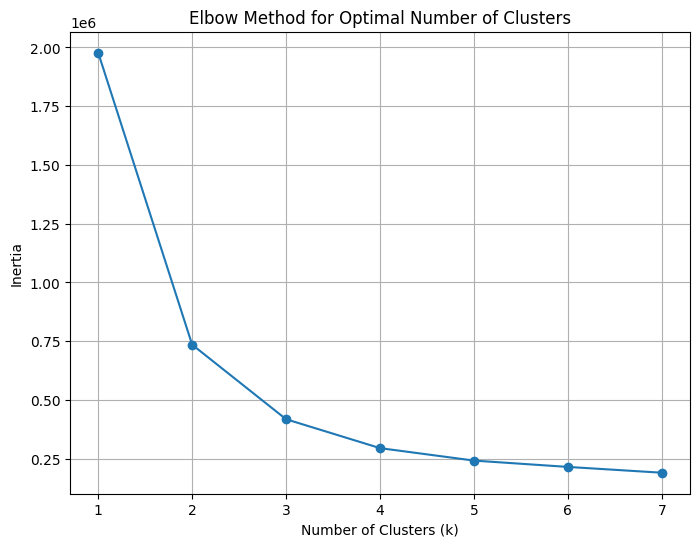

In [36]:
from sklearn.cluster import KMeans
inertia = []
k_range = range(1, 8)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 6))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

In [38]:
optimal_k=5
kmeans=KMeans(n_clusters=optimal_k,random_state=42)
df["cluster"]=kmeans.fit_predict(X)

In [39]:
df.head()

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation,cluster
0,1,0,22,0,5,1.0,2,4.0,3,3,1
2,0,1,67,1,2,1.0,2,1.0,5,1,0
3,1,1,67,1,7,0.0,1,2.0,5,1,0
5,1,1,56,0,0,0.0,0,2.0,5,2,0
6,1,0,32,1,5,1.0,2,3.0,5,2,1


In [43]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(X, df['cluster'])
print(f'Silhouette Score for k={optimal_k}: {sil_score:.3f}')

Silhouette Score for k=5: 0.363


In [45]:
centroids = kmeans.cluster_centers_
centroids_df = pd.DataFrame(centroids, columns=features)

In [47]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations


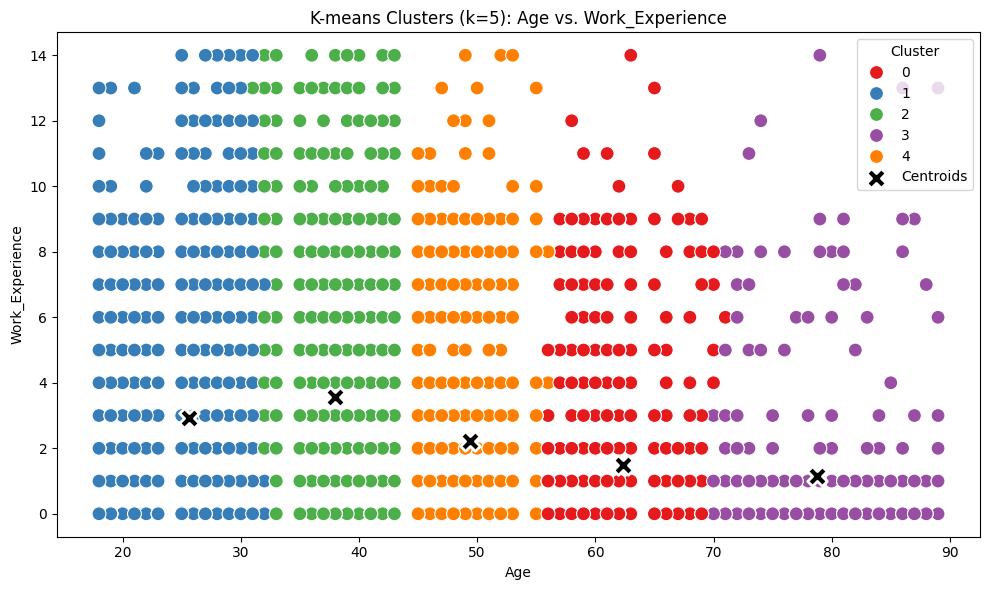

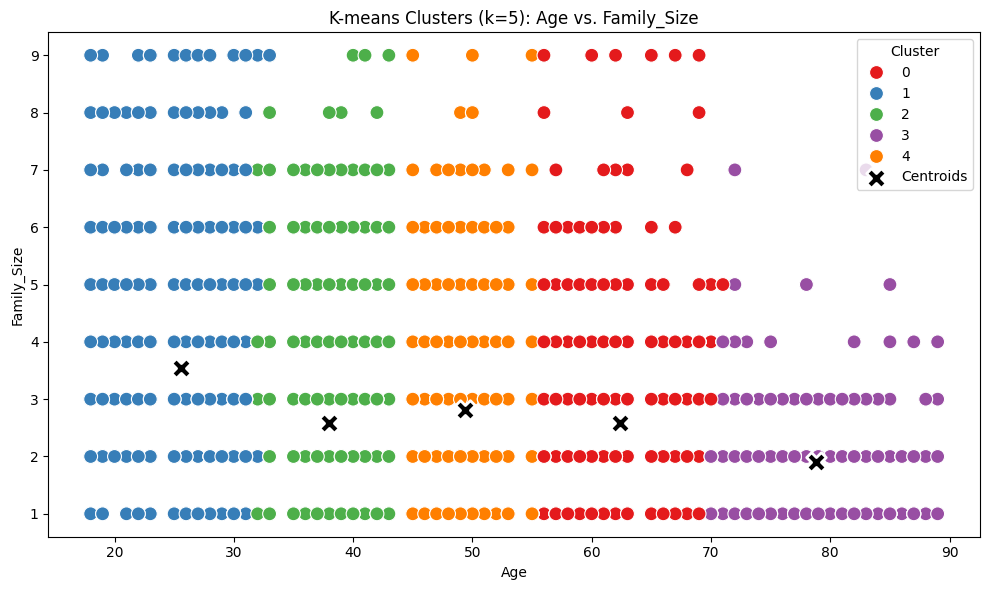

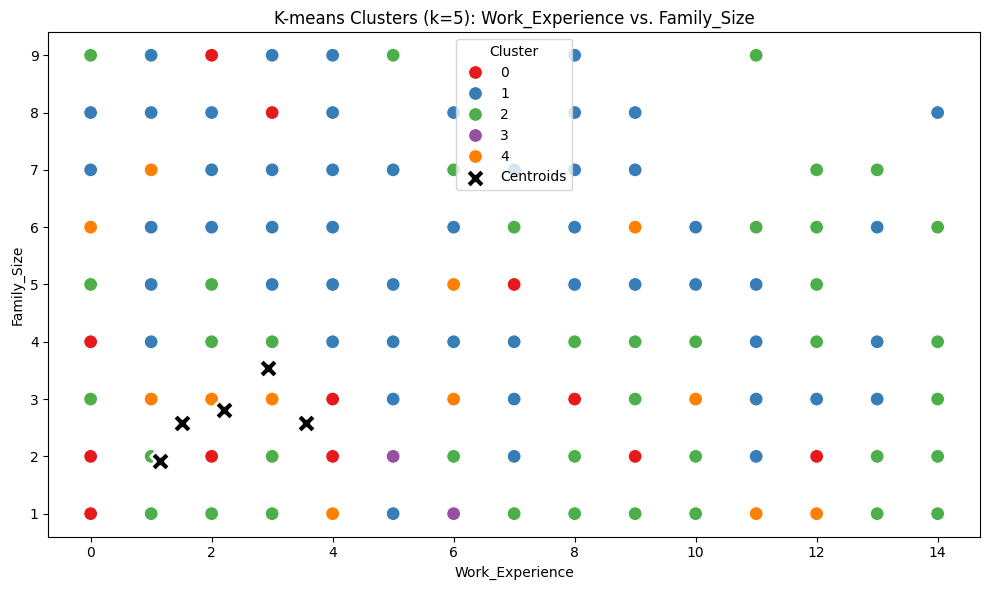

In [50]:
numerical_features = ['Age', 'Work_Experience', 'Family_Size']
feature_pairs = list(combinations(numerical_features, 2))
for x_col, y_col in feature_pairs:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x=x_col, y=y_col, hue='cluster', palette='Set1', s=100)
    plt.scatter(centroids_df[x_col], centroids_df[y_col], c='black', marker='X', s=200,
                label='Centroids', edgecolors='white', linewidth=2)
    plt.title(f'K-means Clusters (k={optimal_k}): {x_col} vs. {y_col}')
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.legend(title='Cluster')
    plt.tight_layout()
    plt.show()

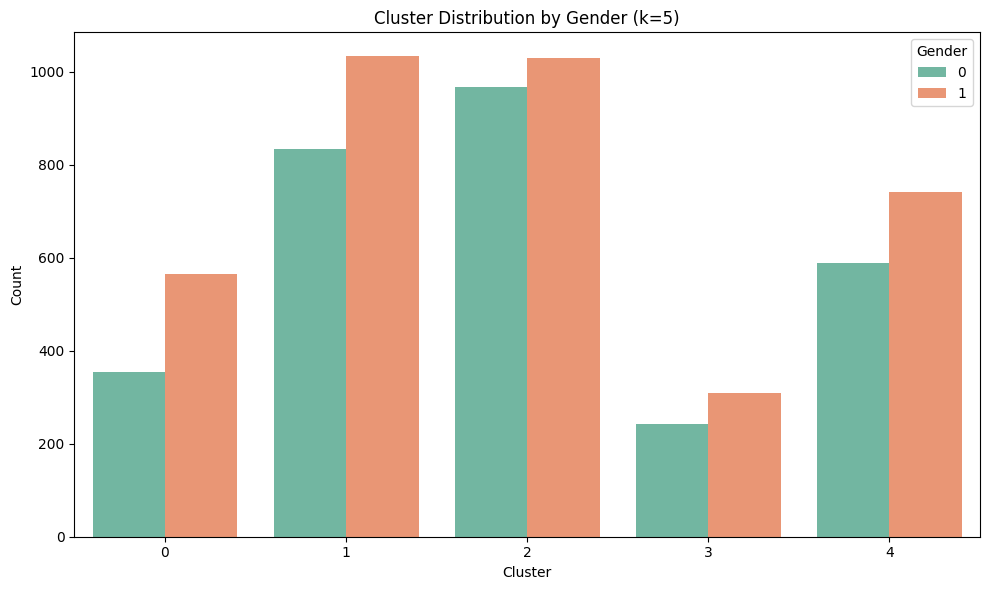

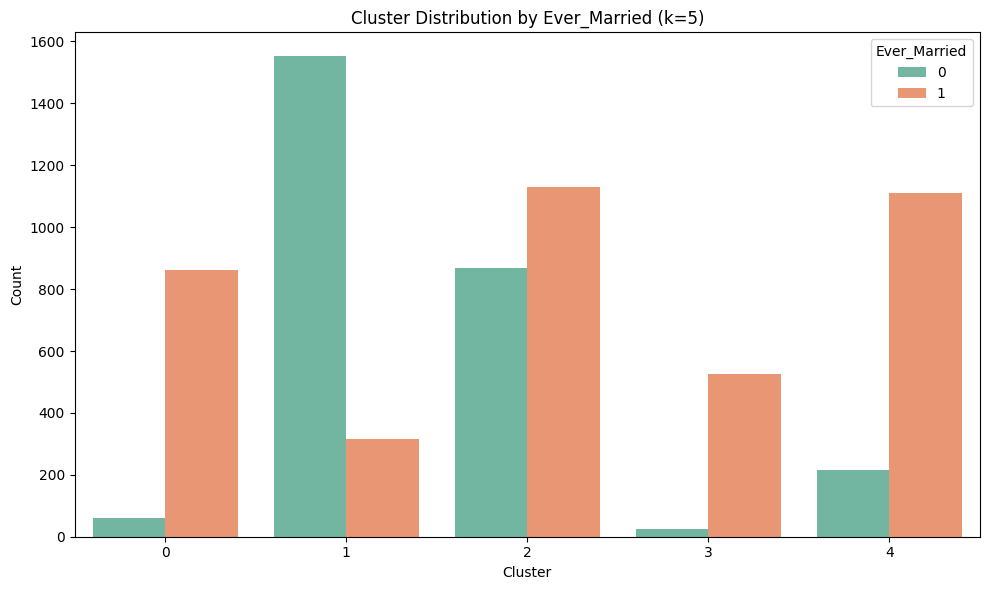

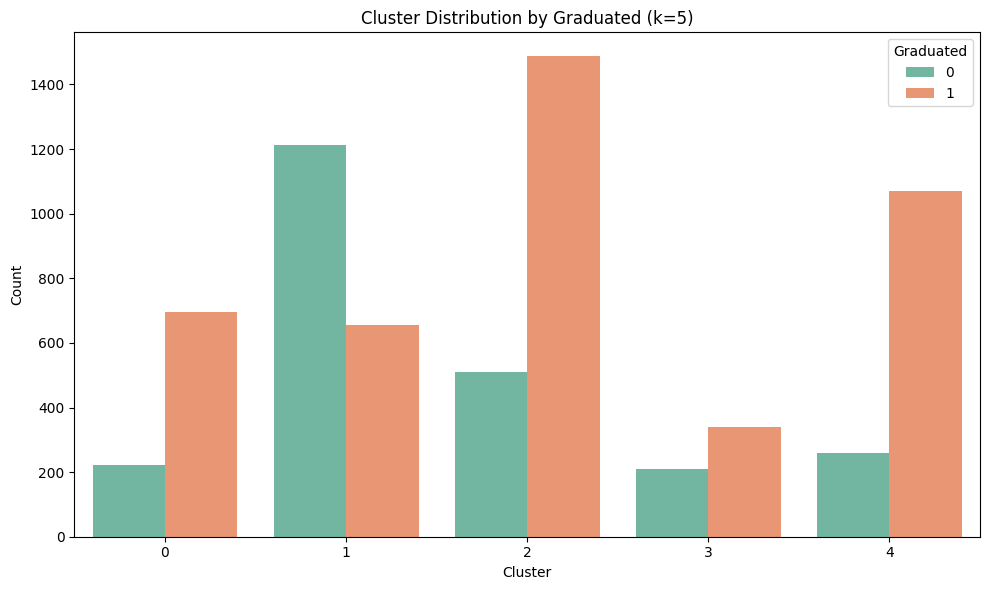

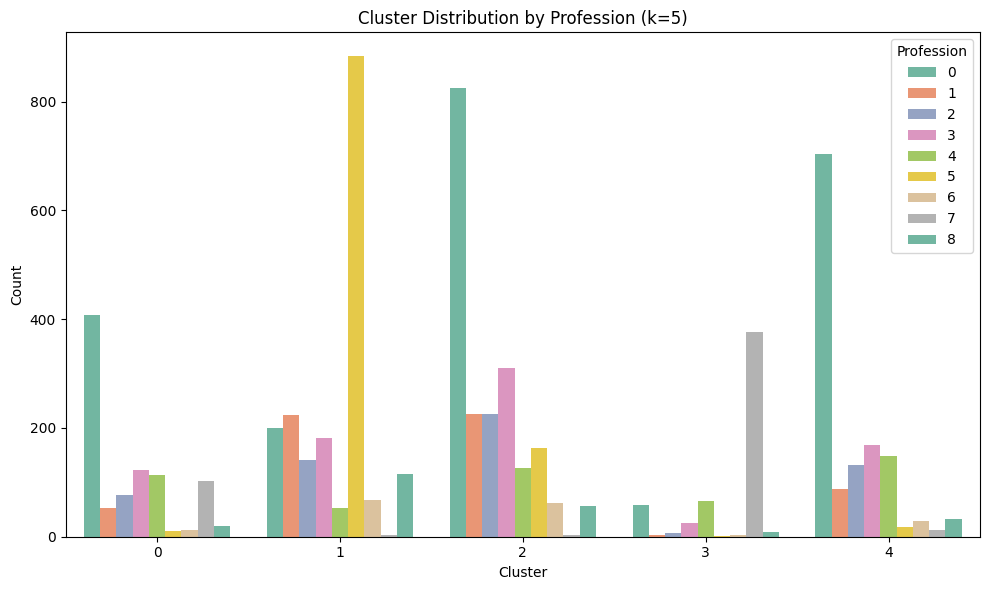

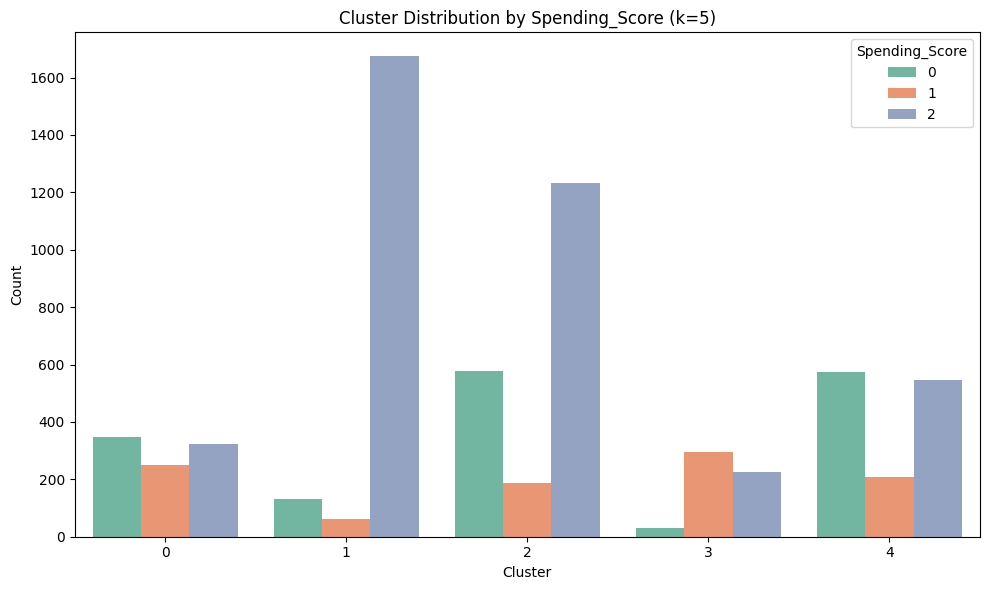

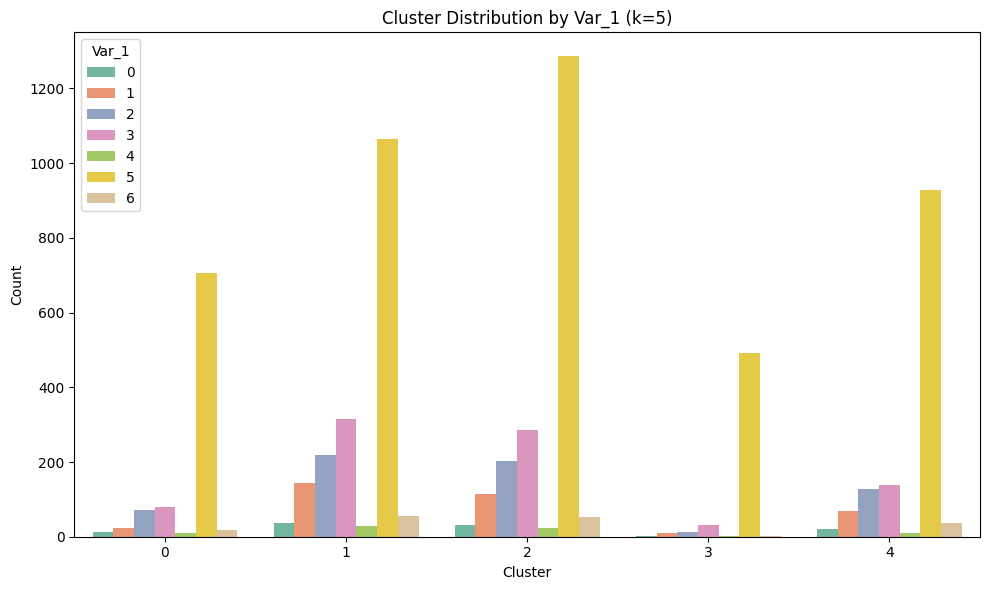

In [52]:
categorical_features = ['Gender', 'Ever_Married', 'Graduated', 'Profession',
                       'Spending_Score', 'Var_1']
for cat_col in categorical_features:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x='cluster', hue=cat_col, palette='Set2')
    plt.title(f'Cluster Distribution by {cat_col} (k={optimal_k})')
    plt.xlabel('Cluster')
    plt.ylabel('Count')
    plt.legend(title=cat_col)
    plt.tight_layout()
    plt.show()

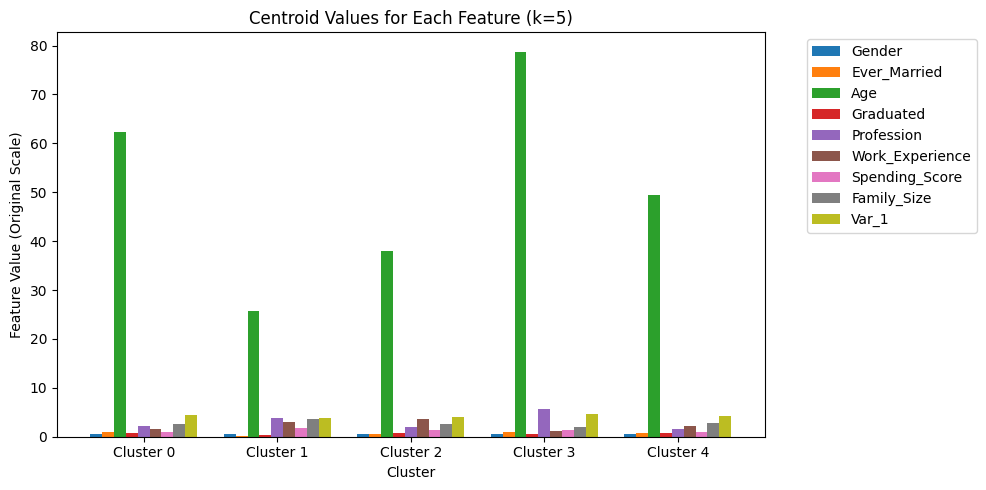

In [55]:
centroids_df.plot(kind='bar', width=0.8,figsize=(10,5))
plt.title(f'Centroid Values for Each Feature (k={optimal_k})')
plt.xlabel('Cluster')
plt.ylabel('Feature Value (Original Scale)')
plt.xticks(ticks=range(optimal_k), labels=[f'Cluster {i}' for i in range(optimal_k)], rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

/tmp/ipython-input-2503238518.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='cluster', palette='Set3')


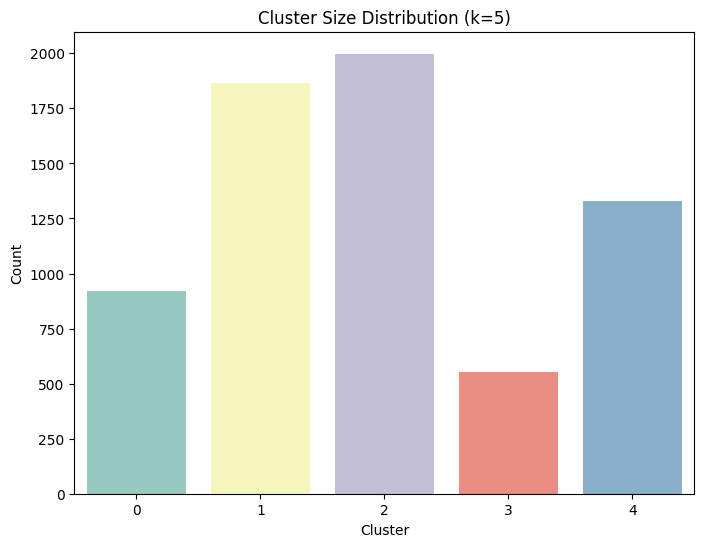

In [57]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='cluster', palette='Set3')
plt.title(f'Cluster Size Distribution (k={optimal_k})')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.show()

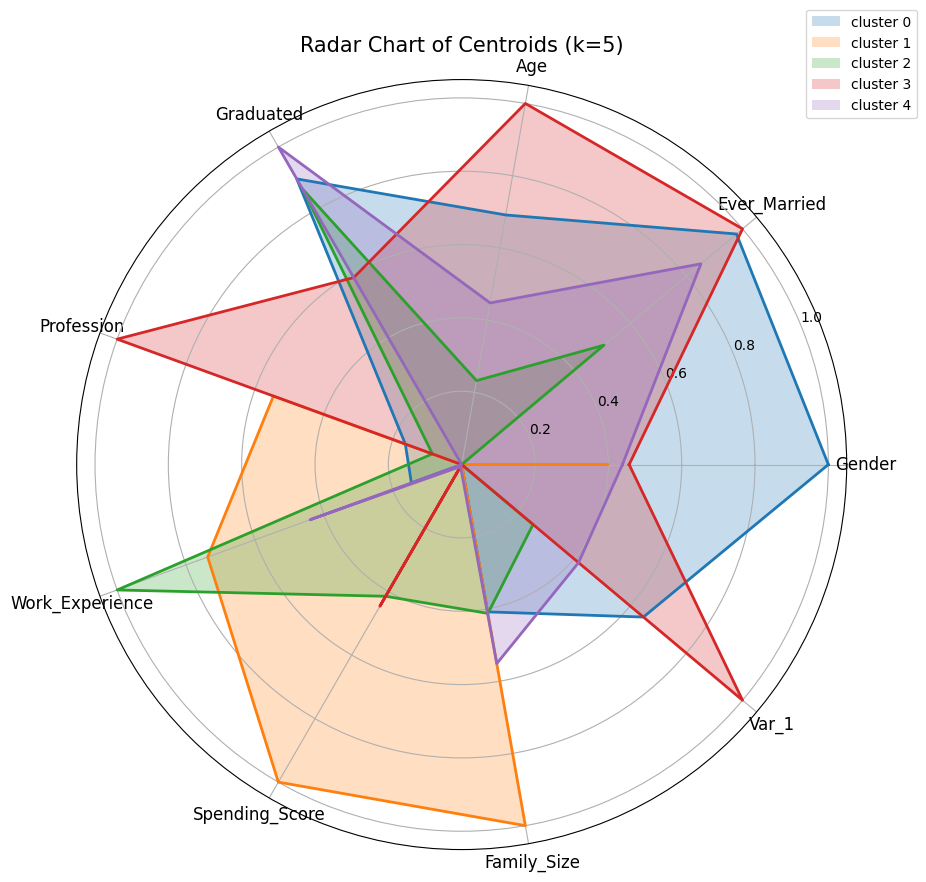

In [58]:
centroids_normalized = (centroids - centroids.min(axis=0)) / (centroids.max(axis=0) - centroids.min(axis=0))
centroids_normalized = np.nan_to_num(centroids_normalized, nan=0.5)  # Handle division by zero
labels = features
num_vars = len(labels)

# Compute angles for radar chart
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # Close the circle

# Initialize radar chart
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
for i in range(optimal_k):
    values = centroids_normalized[i].tolist()
    values += values[:1]  # Close the circle
    ax.fill(angles, values, alpha=0.25, label=f'cluster {i}')
    ax.plot(angles, values, linewidth=2)

# Customize radar chart
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=12)
ax.set_title(f'Radar Chart of Centroids (k={optimal_k})', size=15, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))
plt.show()